<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/PC06_DNA_Methylation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PC06 — DNA Methylation Analysis

Evaluate promoter-associated methylation features and their relationship with gene expression.

In [1]:
# @title Colab setup
!pip -q install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels lifelines networkx umap-learn openpyxl requests

import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Environment ready.")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 6.1 MB/s eta 0:00:00
Environment ready.


In [2]:
genes=["AR","PTEN","RB1","TP53","FOXA1","SPOP","MYC"]
meth=pd.DataFrame(np.random.beta(5,5,(20,len(genes))), columns=genes,
                  index=[f"P{i:03d}" for i in range(1,21)])
display(meth.head())


,AR,PTEN,RB1,TP53,FOXA1,SPOP,MYC
P001,0.571077,0.499998,0.578952,0.385375,0.761260,0.342569,0.672172
P002,0.422107,0.461670,0.629083,0.728028,0.314794,0.561052,0.522162
P003,0.337489,0.581800,0.353994,0.510022,0.433060,0.464250,0.446282
P004,0.617149,0.339523,0.545309,0.434290,0.460583,0.561665,0.407747
P005,0.453057,0.503891,0.368677,0.436090,0.537822,0.260968,0.281166


In [3]:
# Example methylation–expression correlation
expr_demo = pd.DataFrame(np.random.lognormal(2,1,(20,len(genes))), columns=genes, index=meth.index)
corr=[]
for g in genes:
    r,p=__import__("scipy.stats",fromlist=["pearsonr"]).pearsonr(meth[g], expr_demo[g])
    corr.append([g,r,p])
corr=pd.DataFrame(corr,columns=["gene","pearson_r","p"])
display(corr)


,gene,pearson_r,p
0,AR,0.206139,0.383241
1,PTEN,-0.086530,0.716801
2,RB1,0.035054,0.883354
3,TP53,-0.289972,0.214919
4,FOXA1,0.002067,0.993099
5,SPOP,0.093838,0.693945
6,MYC,-0.022419,0.925256


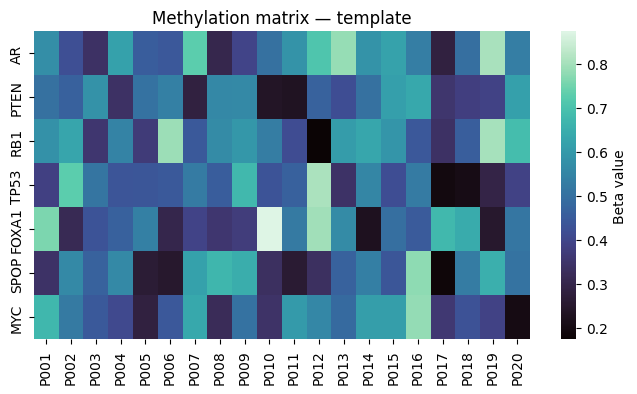

In [4]:
plt.figure(figsize=(8,4))
sns.heatmap(meth.T, cmap="mako", cbar_kws={"label":"Beta value"})
plt.title("Methylation matrix — template")
plt.show()
